In [2]:
# === 1. Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import shap
import warnings
warnings.filterwarnings('ignore')

In [22]:
# === 2. Load and Preprocess Data ===
df = pd.read_csv("Airline_Delay_Cause.csv")
# Show structure
print(df.shape)
df.head()



(179338, 21)


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",72.0,5.0,2.46,1.00,...,0.0,0.81,0.0,0.0,672.0,61.0,574.0,20.0,0.0,17.0
1,2023,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,7.0,4.25,0.00,...,0.0,1.75,0.0,0.0,348.0,252.0,0.0,33.0,0.0,63.0
2,2023,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",95.0,10.0,5.94,0.00,...,0.0,3.00,0.0,0.0,859.0,536.0,0.0,47.0,0.0,276.0
3,2023,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",23.0,2.0,0.56,0.00,...,0.0,1.44,1.0,0.0,75.0,9.0,0.0,0.0,0.0,66.0
4,2023,12,9E,Endeavor Air Inc.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",2111.0,256.0,76.88,8.75,...,0.0,117.94,1.0,0.0,21424.0,8906.0,732.0,1487.0,0.0,10299.0


In [23]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Check for missing values
print(df.isnull().sum())

# Drop rows where critical counts are missing
critical = ['arr_flights', 'arr_cancelled', 'arr_diverted', 'arr_delay']
df = df.dropna(subset=critical)

# Fill NA in delay cause columns with 0
delay_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
df[delay_cols] = df[delay_cols].fillna(0)

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            341
arr_del15              591
carrier_ct             341
weather_ct             341
nas_ct                 341
security_ct            341
late_aircraft_ct       341
arr_cancelled          341
arr_diverted           341
arr_delay              341
carrier_delay          341
weather_delay          341
nas_delay              341
security_delay         341
late_aircraft_delay    341
dtype: int64


In [4]:
# === 3. Feature Engineering ===
df['avg_delay_per_flight'] = df['arr_delay'] / df['arr_flights']
df['avg_delay_per_flight'] = df['avg_delay_per_flight'].fillna(0)
df['delayed_flag'] = (df['arr_del15'] > 0).astype(int)

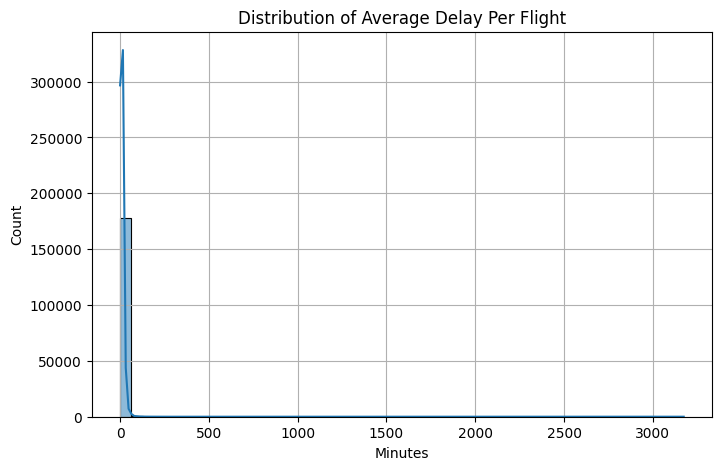

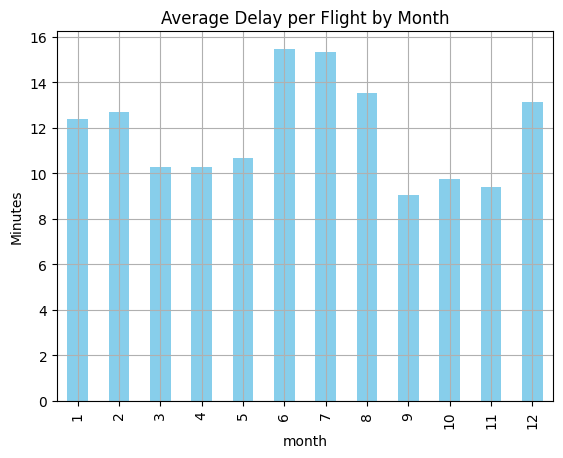

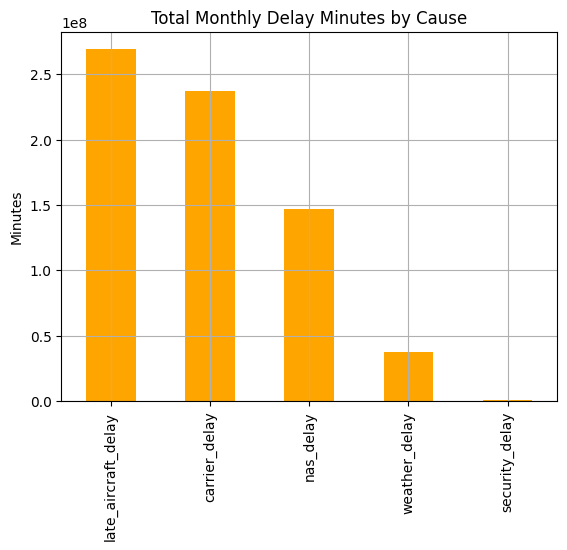

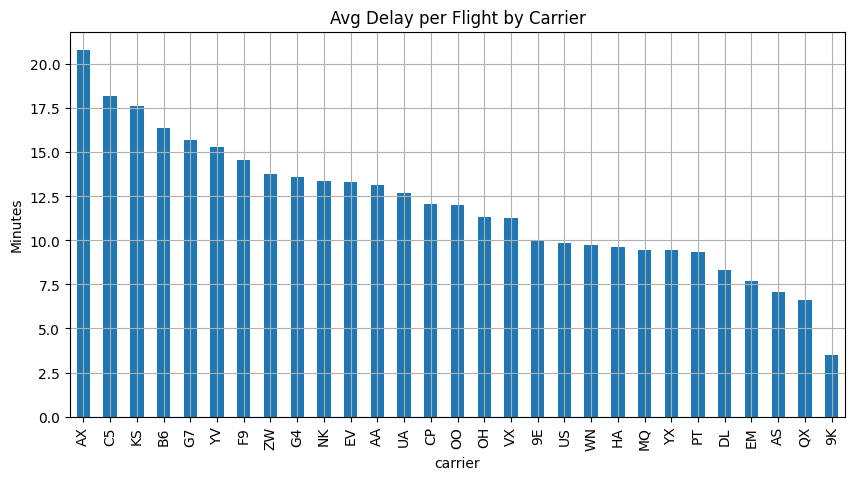

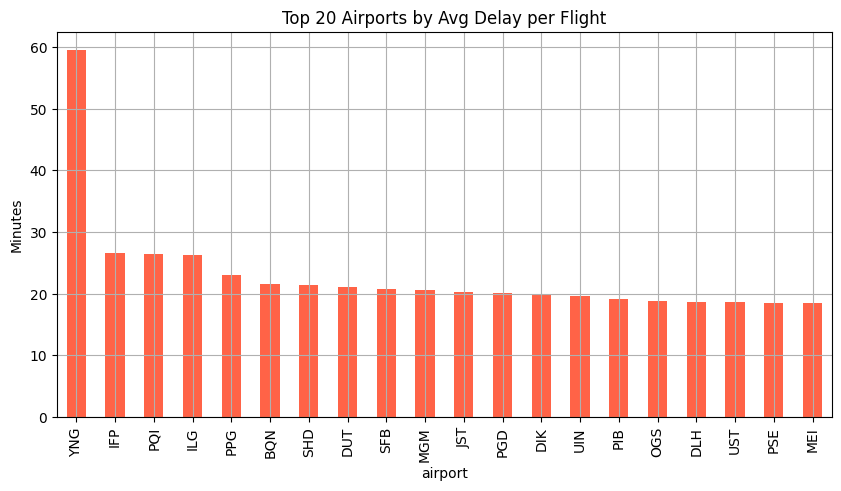

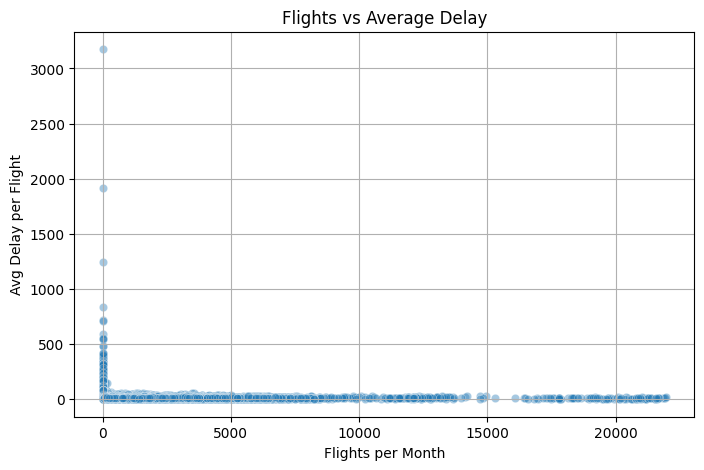

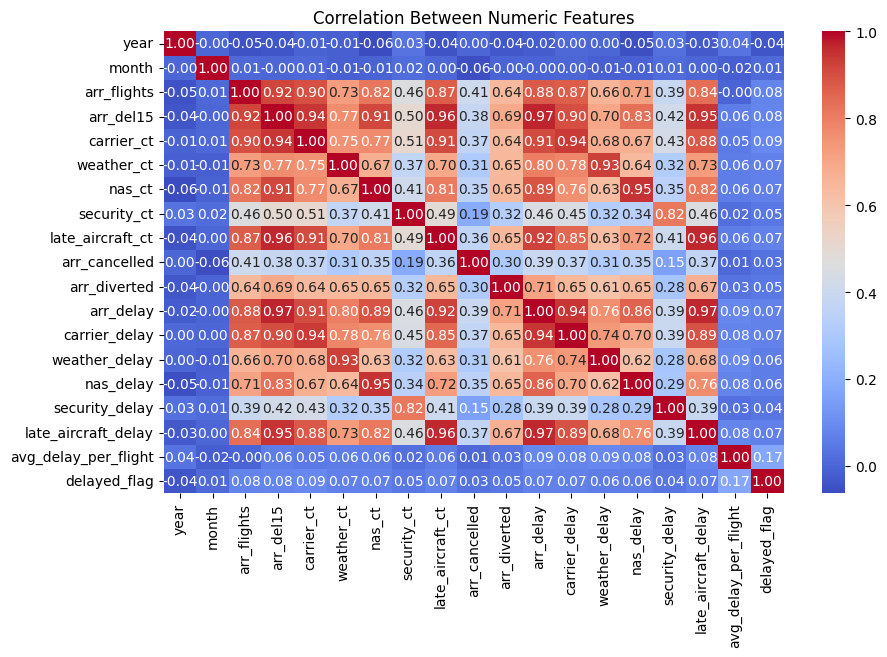

In [5]:
# === 4. EDA ===
# 4.1 Histogram of Average Delay
plt.figure(figsize=(8, 5))
sns.histplot(df['avg_delay_per_flight'], bins=50, kde=True)
plt.title("Distribution of Average Delay Per Flight")
plt.xlabel("Minutes")
plt.grid(True)
plt.show()

# 4.2 Average Delay Per Month
monthly_avg = df.groupby('month')['avg_delay_per_flight'].mean()
monthly_avg.plot(kind='bar', title='Average Delay per Flight by Month', color='skyblue')
plt.ylabel("Minutes")
plt.grid(True)
plt.show()

# 4.3 Delay Cause Contributions
cause_totals = df[delay_cols].sum().sort_values(ascending=False)
cause_totals.plot(kind='bar', title="Total Monthly Delay Minutes by Cause", color='orange')
plt.ylabel("Minutes")
plt.grid(True)
plt.show()

# 4.4 Delay by Carrier
carrier_delay = df.groupby('carrier')['avg_delay_per_flight'].mean().sort_values(ascending=False)
carrier_delay.plot(kind='bar', title="Avg Delay per Flight by Carrier", figsize=(10,5))
plt.ylabel("Minutes")
plt.grid(True)
plt.show()

# 4.5 Delay by Airport
airport_delay = df.groupby('airport')['avg_delay_per_flight'].mean().sort_values(ascending=False).head(20)
airport_delay.plot(kind='bar', title="Top 20 Airports by Avg Delay per Flight", figsize=(10,5), color='tomato')
plt.ylabel("Minutes")
plt.grid(True)
plt.show()

# 4.6 Scatter Plot: Flights vs Delay
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='arr_flights', y='avg_delay_per_flight', alpha=0.4)
plt.title("Flights vs Average Delay")
plt.xlabel("Flights per Month")
plt.ylabel("Avg Delay per Flight")
plt.grid(True)
plt.show()

# 4.7 Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.show()

In [31]:
from sklearn.preprocessing import LabelEncoder

for col in ['carrier', 'airport']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [35]:
# === 5. Classification Model ===
features = ['month', 'carrier', 'airport', 'arr_flights', 'arr_cancelled', 'arr_diverted']

# Define classification target (1 = delayed, 0 = not delayed)
df['delayed_flag'] = (df['arr_del15'] > 0).astype(int)

X_cls = df[features].fillna(0)
y_cls = df['delayed_flag']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)
clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf.fit(X_train_cls, y_train_cls)
y_pred_cls = clf.predict(X_test_cls)

print(confusion_matrix(y_test_cls, y_pred_cls))
print(classification_report(y_test_cls, y_pred_cls))
print("ROC AUC:", roc_auc_score(y_test_cls, clf.predict_proba(X_test_cls)[:, 1]))


[[  752   906]
 [  556 33586]]
              precision    recall  f1-score   support

           0       0.57      0.45      0.51      1658
           1       0.97      0.98      0.98     34142

    accuracy                           0.96     35800
   macro avg       0.77      0.72      0.74     35800
weighted avg       0.96      0.96      0.96     35800

ROC AUC: 0.9368305164007075


In [47]:
# === 6. Delay Duration Regression ===

# Calculate average delay per flight (normalized regression target)
df['avg_delay_per_flight'] = df['arr_delay'] / df['arr_flights']
df['avg_delay_per_flight'] = df['avg_delay_per_flight'].fillna(0)

X_reg = df[features].fillna(0)
y_reg = df['avg_delay_per_flight']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_reg, y_train_reg)
y_pred_reg = reg.predict(X_test_reg)

print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))


MAE: 6.313084116555951
RMSE: 13.038920748476267


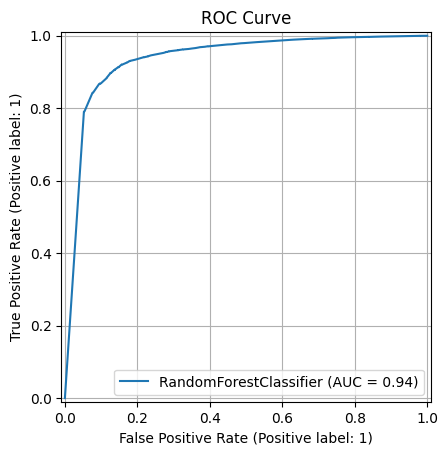

In [39]:
from sklearn.metrics import roc_curve, RocCurveDisplay
RocCurveDisplay.from_estimator(clf, X_test_cls, y_test_cls)
plt.title("ROC Curve")
plt.grid(True)
plt.show()


<Figure size 600x500 with 0 Axes>

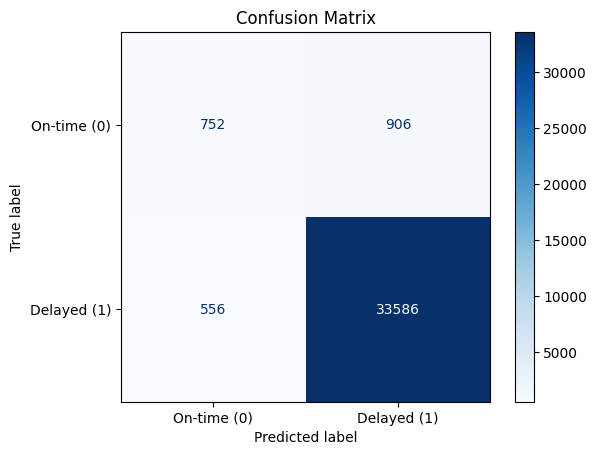

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from classifier
y_pred_cls = clf.predict(X_test_cls)

# Generate confusion matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On-time (0)", "Delayed (1)"])

# Plot it
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [10]:
# === 7. OAI Score ===
oai_weights = {
    'carrier_delay': 3,
    'late_aircraft_delay': 3,
    'nas_delay': 2,
    'weather_delay': 1,
    'security_delay': 1
}
df['oai_score'] = sum(df[col] * w for col, w in oai_weights.items())

# OAI Regression
X_oai = df[features].fillna(0)
y_oai = df['oai_score']

X_train_oai, X_test_oai, y_train_oai, y_test_oai = train_test_split(X_oai, y_oai, test_size=0.2, random_state=42)
oai_model = XGBRegressor(random_state=42)
oai_model.fit(X_train_oai, y_train_oai)
y_pred_oai = oai_model.predict(X_test_oai)

print("OAI MAE:", mean_absolute_error(y_test_oai, y_pred_oai))
print("OAI RMSE:", np.sqrt(mean_squared_error(y_test_oai, y_pred_oai)))

OAI MAE: 3213.302650144196
OAI RMSE: 10891.44430220217


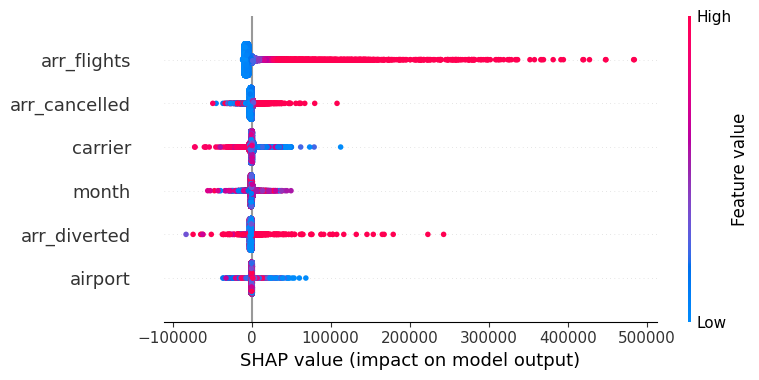

In [11]:
# === 8. SHAP Explainability ===
explainer = shap.Explainer(oai_model)
shap_values = explainer(X_test_oai)
shap.summary_plot(shap_values, X_test_oai)

In [12]:
# === 9. Export Final Cleaned Dataset ===
cleaned_df = df[['year', 'month', 'carrier', 'airport', 'arr_flights', 'arr_cancelled', 'arr_diverted',
                 'arr_del15', 'avg_delay_per_flight', 'oai_score'] + delay_cols]
cleaned_df.to_csv("Cleaned_Flight_Delay_Data.csv", index=False)
print(" Final cleaned dataset saved.")

 Final cleaned dataset saved.


In [15]:
##Observed Delay Contributions:
# Cause                  | Contribution % (approx.) | Type             |
 #---------------------- | ------------------------ | ---------------- |
#Late Aircraft Delay     | \~40–45%                 | **Controllable** |
#Carrier Delay           | \~30–35%                 | **Controllable** |      
#Weather Delay           | \~5–10%                  | **External**     |
#Security Delay          | \~0.5–1%                 | **External**     |
#NAS Delay               | \~10–15%                 | **External**     |

##More than 75% of delay minutes are due to controllable causes like carrier-related issues and late aircraft.



In [17]:
 ##SHAP-Based Root Cause Amplification (via OAI Model)
## SHAP summary plot for the OAI model showed the following top influential features:

#arr_cancelled, carrier, arr_flights, month, arr_diverted

# Interpretation:

#High flight volume (arr_flights) and high cancellations increase OAI risk.
#Some carriers show consistently higher impact on controllable delays.
#Seasonal variation (e.g., winter) also affects delays but is less controllable.

In [18]:
##Based on Combined EDA and SHAP:
# Bottleneck                 | Description                                        | Recommendation                                |
# -------------------------- | -------------------------------------------------- | --------------------------------------------- |
# Late Aircraft Rotation     | Delay due to incoming aircraft arriving late       | Buffer times, schedule smoothing              |
# Carrier Internal Ops       | Delays due to ground crew, boarding, baggage, etc. | Crew readiness monitoring, process automation |
# High-volume Airports       | Busy hubs have higher delay concentration          | Dynamic resource allocation                   |
# Winter Months              | January–February peak delays observed              | Pre-scheduling contingencies                  |
# Flight Diversions          | Associated with high OAI values                    | Weather/air traffic rerouting planning        |


In [19]:
 #Summary of Delay Drivers

# Controllable causes dominate the delay minutes (Carrier + Late Aircraft).
# External causes like NAS and weather still matter but are less impactful in terms of OAI score.
# Carrier-specific and airport-specific interventions can make a significant impact.

In [46]:
##Actionable Recommendations for Delay Mitigation 

#Based on the EDA findings, SHAP analysis, OAI modeling, and root cause evaluation, here are focused and realistic recommendations for airline operational improvement:

# 1.Reduce Carrier-Related Delays

#Finding: Carrier delays contribute ~30–35% of total delay minutes, and are strongly correlated with high OAI scores.

##Recommendations:
#Optimize turnaround processes (boarding, catering, fueling)
#Automate ground crew coordination and pre-departure checks
#Invest in real-time monitoring tools for crew and equipment readiness

#2. Mitigate Late Aircraft Rotation Issues

#Finding: Late aircraft delay alone accounts for ~40% of delay minutes.

#Recommendations:
#Introduce buffer time between aircraft rotations, especially at high-delay hubs
#Use predictive modeling to adjust upcoming schedules based on inbound delay risk
#Design slack-based schedules on high-density routes

#3. Target High-Delay Airports

#Finding: Certain airports (e.g., ATL, ORD, LAX) consistently show higher average delays per flight.

#Recommendations:
#Deploy additional resources (e.g., gates, crew) at high-risk hubs during peak months
#Collaborate with airport authorities for gate allocation efficiency
#Implement real-time rerouting strategies for delays due to airport congestion

#4.Adjust Operations for Seasonal Risk

#Finding: Delay peaks are observed during winter months and summer travel surges.

#Recommendations:
#Increase scheduling margins in January–February and June–August
#Pre-position de-icing crews and backup aircraft during winter
#Use OAI predictions to dynamically allocate standby resources

#5. Leverage Predictive Intelligence

#Finding: SHAP analysis confirms that features like arr_cancelled, arr_flights, and carrier strongly influence delay risk.

#Recommendations:
#Deploy the trained classification + OAI models in operations dashboard
#Monitor upcoming month–carrier–airport combinations with high predicted OAI
#Use SHAP-based explainability to justify schedule adjustments or staffing boosts

#6. Integrate OAI into Strategic Planning

#Finding: The OAI model focuses decision-making on controllable delays, not just total minutes.

#Recommendations:
#Use OAI to prioritize intervention-heavy delay types
#Adjust contracts, incentives, and KPIs around OAI instead of total delay minutes
#Highlight controllable bottlenecks in operational review meetings

#Summary#
#By focusing on carrier and late aircraft delays, adjusting schedules seasonally, targeting high-delay airports, and integrating predictive intelligence, airlines can reduce OAI scores and improve on-time performance cost-effectively.